<a href="https://colab.research.google.com/github/Pulakspbl/GCI_2026/blob/main/Copy_of_lec2_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2 Efficient Data Manipulation Using Numpy

In data science, the moment you collect numeric measurements, the next question is how to store and manipulate them efficiently so you can clean them, summarize them, and eventually visualize and model them. In this notebook, we will learn about Numpy, a core numerical computation library in Python. The notebook covers what NumPy arrays are, why they are more suitable than standard Python lists for numerical data, and how to perform the various operations that you will need when conducting data analysis.

Numpy also serves as a basis of other Python libraries that are frequently used for data science, so let's make sure you have a good understanding of it here.
If you would like to learn Numpy more, please refer to the official documentation ([https://numpy.org/](https://numpy.org/)).

### Table of Contents

- **2.1 Overview of Numpy**
    - 2.1.1 Loading Libraries

- **2.2 Introduction to Numpy**
    - 2.2.1 Basic Operations
    - 2.2.2 Python Lists vs. Numpy Arrays

- **2.3 Numpy Indexing 1**
    - 2.3.1 Single Element Indexing
    - 2.3.2 Slicing
    - 2.3.3 Boolean Indexing

- **2.4 Numpy 2D Arrays**
    - 2.4.1 Creating 2D Arrays
    - 2.4.2 Math Operations
    - 2.4.3 Axis and Aggregation Functions

- **2.5 Numpy Indexing 2**
    - 2.5.1 Indexing
    - 2.5.2 Slicing
    - 2.5.3 Boolean Indexing

- **2.6 Numpy Advanced**
    - 2.6.1 Constants
    - 2.6.2 Numpy Arrays with Random Values
    - 2.6.3 Matrix Calculation

- **2.7 Comprehensive Question**

## 2.1 Overview of Numpy
In data science and machine learning, most “data” eventually becomes numbers arranged as vectors (1D) and matrices (2D), and progress comes from repeatedly applying the same mathematical operations—transformations, summaries, and linear algebra—at scale. Python’s built-in types like lists are **great for general-purpose programming**, but they are **not designed for efficient numerical computation**. For example, you may experience writing many loops, re-implementing common routines, and producing code that is harder to read and slower to run as the dataset grows. **NumPy** fills that gap by providing a **dedicated array object** and a rich set of fast, consistent operations for numerical data, which is why it sits underneath much of the Python data stack.

### 2.1.1 Loading Libraries

We will first need to import the Numpy library.

In Python, there are mainly two syntaxes for loading a library.

```
(1) `import` library_name `as` alias

(2) `from` library_name `import` module/function_name
```

(1) is used to load the entire library.

(2) can be used to load modules or functions in a hierarchical library.

Use it according to your purpose.

The following cell imports Numpy library with the alias `np`. Numpy is generally loaded with the alias `np`. You can choose to use other aliases, but this may result in lower interpretability of the code.

In [ ]:
import numpy as np

Numpy is hierarchical in its functionality, consisting of many modules and functions to serve various purposes (e.g. random generator, matrix operation, etc.). In the following cell, we will import specific modules using `from numpy import module_name`.

In [ ]:
from numpy import random
from numpy import linalg as LA

This imports `random` and `linalg` module from Numpy library. For `linalg` module, it is imported with the alias `LA`. By doing this, you can code more efficiently as you can write, for example, `random.function_name()` instead of `np.random.function_name()`.

## 2.2 Introduction to Numpy

Numpy is a powerful library for numerical computing in Python. It provides support for arrays, matrices, and a vast collection of mathematical functions to operate on them. While Python list is mainly a flexible container for holding objects, Numpy array (`numpy.ndarray`) is a multi-dimensional data structure that can hold elements of the same data type. It is optimized for optimized for numerical operations by storing data in a compact and contiguous memory block. This makes Numpy a perfect choice to store and analyze data efficiently and conveniently, making them the backbone of many machine learning and data science workflows.

Python's List can easily be converted into a `numpy.ndarray` using the `np.array()` function.


In [ ]:
# Python list
a = [1, 2, 3, 4, 5]
b = [6, 7, 8, 9, 10]

# Convert list to np.ndarray
a = np.array(a)
b = np.array(b)

print("a: ", a)
print("b: ", b)
# Checking the type of a and b
print("type of a:", type(a))
print("type of b:", type(b))

a:  [1 2 3 4 5]
b:  [ 6  7  8  9 10]
type of a: <class 'numpy.ndarray'>
type of b: <class 'numpy.ndarray'>


To convert from `np.ndarray` to a Python list, you can use the `.tolist()` method.

In [ ]:
a_list = a.tolist()  # Convert np.ndarray back to list

print(a_list)
print(type(a_list))

[1, 2, 3, 4, 5]
<class 'list'>


Key Features of `numpy.ndarray`:
- **Homogeneous**: All elements are of the same type.
- **Efficient**: Designed for performance in numerical computations.
- **Flexible**: Supports slicing, indexing, and advanced operations.

### 2.2.1 Basic Operations

In this section, we will introduce the basic operations of `np.ndarray`. The fundamental concept of Numpy operations here is **universal**. By universal operations, we mean applying operations individually to each element of an array.

Let’s experience this by looking at some examples. Here, we will assume as situation where the target data is available on the Web as a CSV file, which can be downloaded and used.

Although it is possible to download the data in advance from a browser, Python can also directly read and save the data, so this section explains how to download the data using Numpy.

#### Downloading the Dataset
We will use the [sample dataset from NOAA](https://www.ncdc.noaa.gov/cdo-web/datasets) which contains data of daily temperature and precipitation recorded at one of the weather observing stations operated by NOAA (National Oceanic and Atmospheric Administration, USA).

The first few rows of the data looks like this:
| STATION | STATION_NAME | ELEVATION | LATITUDE | LONGITUDE | DATE | TMAX | TMIN | PRCP |
|:---:|:---|:---|:---|:---|:---|:---|:---|:---|
| GHCND:USC00327027 | PETERSBURG 2 N ND US | 466.3 | 48.0355 | -98.01 | 20100101 | -178 | -311 | 0 |
| GHCND:USC00327027 | PETERSBURG 2 N ND US | 466.3 | 48.0355 | -98.01 | 20100102 | -244 | -322 | 0 |
| GHCND:USC00327027 | PETERSBURG 2 N ND US | 466.3 | 48.0355 | -98.01 | 20100103 | -194 | -289 | 0 |
| GHCND:USC00327027 | PETERSBURG 2 N ND US | 466.3 | 48.0355 | -98.01 | 20100104 | -167 | -200 | 15 |

The columns represent:
- `STATION`, `STATION_NAME`, `ELEVATION`, `LATITUDE`, `LONGITUDE`: location of the station
- `DATE`: date of record in YYYYMMDD format
- `TMAX`: maximum temperature, measured in tenths of degrees Celsius ($^\circ{C}$)
- `TMIN`: minimum temperature, measured in tenths of degrees Celsius ($^\circ{C}$)
- `PRCP`: precipitation, measured in tenths of millimeters ($mm$)

To download and load the dataset as `np.array`, we will use `np.loadtxt()` function. The extra arguments are used to shape the data in the desired format:
- `delimiter=','`: specify delimiter as a comma ',' (default)
- `usecols=[6,7,8]`: import 7th to 9th columns from the CSV (note: Python indices start from 0)
- `skiprows=1`: do not use the 1st row, as this is a header row

Run the following cell to download and load the data.

In [ ]:
URL = "https://www.ncei.noaa.gov/pub/data/cdo/samples/GHCND_sample_csv.csv"

raw = np.loadtxt(URL, delimiter=",", usecols=[6,7,8], skiprows=1)

For the remaining of this section, we will use only a subset of the data for simplicity by slicing the data (details on slicing will be covered in 2.3.2).

In [ ]:
week_one_tmax = raw[0:7, 0]
week_one_tmin = raw[0:7, 1]
week_one_prcp = raw[0:7, 2]
week_two_tmax = raw[7:14, 0]
print("Week 1 TMAX:", week_one_tmax)
print("Week 1 TMIN:", week_one_tmin)
print("Week 1 PRCP:", week_one_prcp)

Week 1 TMAX: [-178. -244. -194. -167. -133. -133. -150.]
Week 1 TMIN: [-311. -322. -289. -200. -167. -172. -278.]
Week 1 PRCP: [   0.    0.    0.   15. 9999. 9999.    0.]


The length of a one-dimensional array can be obtained using `len()`, just like for Python lists. However, it is more common to use `shape` attribute of the array.

In [ ]:
# Check the size of the arrays
print("Size of Week 1 TMAX:", len(week_one_tmax))

# Alternatively, we can check the shape of the arrays
print("Size of Week 1 TMAX:", week_one_tmax.shape)

Size of Week 1 TMAX: 7
Size of Week 1 TMAX: (7,)


#### Math Operations

Math operations can be performed using the same symbols as in regular Python numeric types. These operations return the result for each element individually (**universal!**)

```python
a = np.array([1, 2, 3, 4, 5])
b = np.array([2, 2, 3, 6, 1])

print("Sum:", a + b)
> Sum: [ 3  4  6 10  6]
print("Difference:", a - b)
>
Difference: [-1  0  0 -2  4]
print("Product:", a * b)
>
Product: [ 2  4  9 24  5]
print("Quotient:", a / b)
> Quotient: [0.5  1.  1. 0.66666667  5.]
```

Let's look at this using the NOAA data.

Since `TMAX` and `TMIN` are measured in tenths of degrees Celsius, we can divide by 10 to convert to degrees Celsius. `PRCP` should be divided by 10 to convert to millimeters.

In [ ]:
week_one_tmax = week_one_tmax / 10
week_one_tmin = week_one_tmin / 10
week_one_prcp = week_one_prcp / 10
print("Week 1 TMAX (in Celsius):", week_one_tmax)
print("Week 1 TMIN (in Celsius):", week_one_tmin)
print("Week 1 PRCP (in mm):", week_one_prcp)

Week 1 TMAX (in Celsius): [-17.8 -24.4 -19.4 -16.7 -13.3 -13.3 -15. ]
Week 1 TMIN (in Celsius): [-31.1 -32.2 -28.9 -20.  -16.7 -17.2 -27.8]
Week 1 PRCP (in mm): [  0.    0.    0.    1.5 999.9 999.9   0. ]


We can then calculate metrics such as daily temperature range.

In [ ]:
week_one_trange = week_one_tmax - week_one_tmin
print("Week 1 TRANGE (in Celsius):", week_one_trange)

Week 1 TRANGE (in Celsius): [13.3  7.8  9.5  3.3  3.4  3.9 12.8]


Other functions, such as built-in functions of Python lists (such as `max` and `sum`) are also implemented in Numpy.

In [ ]:
print("Hottest day in Week 1:", np.max(week_one_tmax))
print("Total rainfall in Week 1:", np.sum(week_one_prcp))
print("Average TMAX in Week 1:", np.mean(week_one_tmax)) # mean is the average
print("Standard deviation of TMAX in Week 1:", np.std(week_one_tmax)) # std is the standard deviation

Hottest day in Week 1: -13.3
Total rainfall in Week 1: 2001.3
Average TMAX in Week 1: -17.128571428571426
Standard deviation of TMAX in Week 1: 3.6354265954097102


##### Note: Division by zero

In standard Python, division by zero leads to an error.

In [ ]:
2 / 0

ZeroDivisionError: division by zero

However, Numpy processes this differently.

In [ ]:
a = np.array([1, 2, 3])

a / 0

In the example, `inf` appears because of division by zero. This is a special number defined by numpy as `np.inf`, representing infinity. Additionally, a warning message is displayed indicating a division by zero occurred.
Some functions in libraries like scikit-learn, which will be covered in this course, may raise errors if `np.inf` is present.

#### Other Functions

Other mathematical functions implemented are also computed universally. We provide some examples below.

Precipitation distributions are usually very skewed (lots of dry days, a few heavy rain days). A common way to transform this data is `np.log1p()`, which calculates $\log(1+x)$.

In [ ]:
log_prcp = np.log1p(week_one_prcp)  # log1p to avoid log(0)
print("Log-transformed PRCP:", log_prcp)

This can be converted back by using `np.expm1()`, which calculates $\exp(x)-1$.

In [ ]:
inv_prcp = np.expm1(log_prcp)  # expm1 to reverse log1p
print("Inverse log-transformed PRCP:", inv_prcp)

To view the entire list of universal functions, please refer to the [documentation](https://numpy.org/doc/stable/reference/ufuncs.html).

#### Conditional Operations

In Python, normal conditional operations (like `==` or `>`) return boolean values (`True` or `False`).

```python
3 > 5
> False
```

With `np.ndarray`, conditional operation returns the result of the conditional operation for each element as `np.ndarray`, not a bool value (**universal!**). This is different from the behavior with Python lists.

```python
a = np.array([1, 2, 3, 4, 5])
b = np.array([2, 2, 3, 6, 1])

print("a==a:", a==a)
> a==a: [ True  True  True  True  True]
print("a==b:", a==b)
> a==b: [False  True  True False False]
print("a>b:", a>b)
> a>b:  [False False False False  True]
print("Type of a==b:", a==b)
> Type of a==b: <class 'numpy.ndarray'>
```

Let's look at this using the NOAA data.

For example, we can find which days did not rain by comparing `PRCP` with 0.

In [ ]:
print("Week 1 precipitation is zero:", week_one_prcp == 0)
print("Type of the boolean array:", type(week_one_prcp == 0))

We can also find the days in which the minimum temperature is below -10 degrees Celsius.

In [ ]:
print("Week 1 TMIN less than -10°C:", week_one_tmin < -10)

#### Broadcasting

In Numpy, when performing a universal binary operation on two arrays with different lengths or dimensions, one of the arrays is automatically broadcast to match the other in terms of dimensions and length. This is called **broadcasting**.

Let's learn about broadcasting using one-dimensional arrays (vectors) as an example.

The simplest broadcasting example is when an arry and a scalar value are combined in an operation.

In [ ]:
a = np.array([1, 2, 3])

print("2a =", 2 * a)

The number `2` is an `int`, and Numpy treats it as a 0-dimensional array (scalar). However, to perform a universal binary operation like * with the 1-dimensional array a (which has length 3), the other operand must also be a 1-dimensional array of length 5.

Here, Numpy first automatically converts `2` into a 0-dimensional `np.array(2)`. Then, to match the dimensions, it converts it into a 1-dimensional array `np.array([2])`. To match the length, Numpy automatically expands `np.array([2])` into `np.array([2, 2, 2])`, repeating the same value, and then performs the calculation.

![Numpy broadcast](https://numpy.org/doc/stable/_images/broadcasting_1.png)

Reference URL: https://numpy.org/doc/stable/_images/broadcasting_1.png

You can see this by performing the following calculation and checking that it outputs the same result.

In [ ]:
twos = np.array([2, 2, 2])

print("2a =", twos * a)

Now, let's consider what happens when we perform a binary operation on two 1-dimensional arrays.

In [ ]:
b = np.array([1, 2, 3, 4, 5])
c = np.array([1, 2])

print("b + c =", b + c)  # This will raise an error due to shape mismatch

An error will occur here. In broadcasting, when aligning dimensions and lengths, the length must be 1 in order for Numpy to repeat and match the length. If the length is not 1, Numpy cannot automatically broadcast the array.

### 2.2.2 Python Lists vs. Numpy Arrays

#### Why Use Numpy?
As explained preivously, in data science, you spend most of your time doing numeric operations on collections of values: converting units, computing statistics, filtering rows, and preparing feature matrices for plotting and machine learning. Python lists can store those values, but they are general-purpose containers, not numeric computing tools. **Numpy arrays are designed for this purpose at scale**:
- **Convenience**: It provides a rich set of functions for numerical tasks.
- **Performance**: Numpy operations are optimized using C and Fortran, leading to faster computations even for large datasets.

In [ ]:
# Convert week_one_tmax and week_one_tmin to lists for demonstration
week_one_tmax_list = week_one_tmax.tolist()
week_one_tmin_list = week_one_tmin.tolist()

#### Numpy's Strengths (1): Convenience

##### Example 1: Single list/array operation

Using NOAA dataset, let's consider calculating the mean `TMAX`.

When using Python lists, you would need to write the following.

In [ ]:
week_one_tmax_list_mean = sum(week_one_tmax_list) / len(week_one_tmax_list)
print("Average TMAX in Week 1:", week_one_tmax_list_mean)

However, Numpy allows to do this operation much conveniently, as the function is already implemented.

In [ ]:
week_one_tmax_mean = np.mean(week_one_tmax)
print("Average TMAX in Week 1:", week_one_tmax_mean)

##### Example 2: Multiple list/array operation

Next, consider calculating the mean range of temperature.

In [ ]:
def mean_range(tmin_list, tmax_list):
    assert len(tmin_list) == len(tmax_list) # Return an error if the lengths of the lists are not the same

    trange_list = []
    for tmin, tmax in zip(tmin_list, tmax_list):
        trange = tmax - tmin
        trange_list.append(trange)

    return sum(trange_list) / len(trange_list)

week_one_trange_list_mean = mean_range(week_one_tmin_list, week_one_tmax_list)
print("Average range of temperature in Week 1:", week_one_trange_list_mean)

Again, Numpy allows to do this operation conveniently.

In [ ]:
print("Average range of temperature in Week 1:", np.mean(week_one_tmax - week_one_tmin))

Numpy already provides a rich set of basic operations and functions, so there's no need to implement them from scratch in Python.

#### Numpy's Strengths (2): Performance
>
Another major advantage to using Numpy is its **execution time**. Numpy is internally written in C, and for matrix operations, it uses a high-performance matrix computation library called the BLAS API, which makes it much faster than Python for similar tasks.

In [ ]:
import time

# Create a large Python list and a Numpy array
size = 10**6
python_list = list(range(size))
numpy_array = np.arange(size)

# Time the summation for Python list
start = time.time()
list_sum = sum(python_list)
end = time.time()
print("Python List Summation Time:", end - start)

# Time the summation for Numpy array
start = time.time()
array_sum = np.sum(numpy_array)
end = time.time()
print("Numpy Array Summation Time:", end - start)

Try changing the `size` and see how their performance changes.

#### Side Note: Concatenation of list vs numpy array

In data analysis, you sometimes need to extend a time series: for example, you loaded one month of precipitation and then you want to attach the next month. With Python lists, `+` means concatenation.

In [ ]:
week_one_tmax_list = week_one_tmax.tolist()
week_two_tmax_list = week_two_tmax.tolist()

week_one_two_tmax_list = week_one_tmax_list + week_two_tmax_list
print("Combined Week 1 and Week 2 TMAX list:", week_one_two_tmax_list)

With Numpy arrays, `+` means elementwise addition. Instead, Numpy allows concatenation using `np.concatenate()` function.

In [ ]:
week_one_two_tmax = np.concatenate((week_one_tmax, week_two_tmax))
print("Combined Week 1 and Week 2 TMAX array:", week_one_two_tmax)

### <Practice Question 2-1>

(1) Create two 1-dimensional `np.ndarray` arrays with your favorite values as elements, and use the `type()` function to confirm that they are of type `np.ndarray`.


In [ ]:
# (1)
# WRITE ME

(2) Perform arithmetic operations on the two 1-dimensional arrays created in (1).

In [ ]:
# (2)
# WRITE ME

(3) Create a function that takes a 1-dimensional array as input and outputs a 1-dimensional array where the input is normalized.

Here, normalization of a vector (using the L2 norm) means scaling the original vector so that the square root of the sum of the squares of all its elements equals 1.

In this task, please implement the function using only **Numpy's universal operations and functions**.








In [ ]:
def normalize(a):
    # WRITE ME
    return a

## 2.3 Numpy Indexing 1
In this section, you will learn how to use indexing with `np.ndarray` in 1D arrays.

We will continue working with NOAA dataset. Using slicing (see Section 2.3.2), we will use only the data from January, 2010 (note: data starts from January 1st, 2010).

In [ ]:
jan_tmax = raw[0:31, 0]
jan_tmin = raw[0:31, 1]
jan_prcp = raw[0:31, 2]

jan_tmax = jan_tmax / 10
jan_tmin = jan_tmin / 10
jan_prcp = jan_prcp / 10

### 2.3.1 Single Element Indexing
Just as for Python lists, you can retrieve values of Numpy's 1D arrays at any position using `[]`. The use of negative indices corresponds to counting from the end of the array.

Note:
- Indexing starts from 0
- Indexing from the back starts from -1

```python
a = np.array([1, 2, 3, 4, 5])

a[0]
> 1
a[1]
> 2
a[-1]
> 5
a[-2]
> 4
```

For example, we can find out what was the maximum temperature (`TMAX`) on the first recorded day.

In [ ]:
print("First day of January TMAX:", jan_tmax[0])

Using negative indices, we can find out what the data looks like at the end of January, 2010.

In [ ]:
print("Last day of January TMAX:", jan_tmax[-1])
print("Last day of January TMIN:", jan_tmin[-1])
print("Last day of January PRCP:", jan_prcp[-1])

Contrary to Python list, you can specify multiple indices as a list to retrieve multiple values at once in Numpy.

In [ ]:
print("January TMAX every week (in order):", jan_tmax[[0, 7, 14, 21, 28]])
print("January TMAX every week (in random order):", jan_tmax[[7, 0, 14, 28, 21]])

### 2.3.2 Slicing
Just as Python lists, slicing of Numpy array follows the format `start:end:step`. This means that the indices to be extracted from the list form an arithmetic sequence, starting at `start`, with a common difference of `step`, and ending with the largest number less than `end`.
Here, `start`, `end`, and `step` can be omitted. When omitted, `start` defaults to 0, `end` defaults to the last element, and `step` defaults to 1. (If `step` is negative, values are retrieved in reverse order.)

```python
a = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

print("When start is omitted:", end='\t')
print(a[:15:3])
> When start is omitted:        [ 0  3  6  9]

print("When end is omitted:", end='\t')
print(a[2::3])
> When end is omitted:          [ 2  5  8]

print("When step is omitted (1):", end='\t')
print(a[2:15:])
> When step is omitted (1):     [ 2  3  4  5  6  7  8  9]

# The last ":" can also be omitted
print("When step is omitted (2):", end='\t')
print(a[2:15])
> When step is omitted (2):     [ 2  3  4  5  6  7  8  9]

print("When step and end are omitted:", end='\t')
print(a[2:])
> When step and end are omitted: [ 2  3  4  5  6  7  8  9]

```


For example, we can take the first 7 days and compute the average max temperature.

In [ ]:
tmax_week1 = jan_tmax[0:7] # [:7] also works
print("Average TMAX in Week 1:", np.mean(tmax_week1))

We can also look at precipitation on Fridays (Jan 1st, 2010 is Friday). This is helpful for quick downsampling or periodic inspection.

In [ ]:
prcp_fri = jan_prcp[0::7] # [::7] also works
print("January PRCP on Fridays:", prcp_fri)

### 2.3.3 Boolean Indexing

**Boolean indexing** is a powerful feature in Numpy that allows you to filter elements of an array based on a condition. It uses a boolean array (an array of `True` and `False` values) to select elements from another array. This makes it easy to perform conditional filtering and subsetting of data.

```python
a = np.array([1, 1, 2, 3, 5, 8, 13])

# Create a list of boolean values
idx = [True, False, False, True, False, True, True]

# Boolean indexing
print(a[idx])
> [ 1  3  8 13]
```

Let's look at an actual example.

For example, we can look at the `TMAX` and `TMIN` of days without rain.

In [ ]:
no_rain = jan_prcp == 0
print("TMAX on days with no rain (first 10):", jan_tmax[no_rain][:10])
print("TMIN on days with no rain (first 10):", jan_tmin[no_rain][:10])

If you look carefully at `PRCP`, you will notice that some data are extremely large (9999), which represents that precipitation was not properly recorded on that day (**missing value**).

In [ ]:
jan_prcp[:7]

Therefore, when calculating the average precipitation, we should ignore these data.

In [ ]:
# This will lead to wrong average
print("Average January PRCP (including missing values):", np.mean(jan_prcp))

jan_prcp_no_missing = jan_prcp[jan_prcp < 999.9]
print("Average January PRCP (excluding missing values):", np.mean(jan_prcp_no_missing))

We can also combine multiple conditions using the following operators.

- `&`: AND operator
- `|`: OR operator
- `~`: NOT operator

For example, we can find how many days where `TMAX` was below -10 degrees Celsius **AND** not rainy.

In [ ]:
cold_and_not_rainy = (jan_tmax < -10) & (jan_prcp == 0)
print("Number of days in January that are cold and not rainy:", np.sum(cold_and_not_rainy))

### <Practice Question 2-2>

(1) For any array you create, retrieve and display the first value from the front and the first value from the back.

In [ ]:
a = np.array([])
print("First value from the front:")

print("First value from the back:")

(2) Implement a function that takes a one-dimensional Numpy array with integer values as an argument and outputs an array containing elements that are either odd (leave a remainder of 1 when divided by 2) or leave a remainder of 2 when divided by 4.

In [ ]:
# (2)
def make_bool_ids(a):
    # WRITE ME
    return b # b is `np.ndarray`

In [ ]:
# Input example
a = np.array([1, 1, 2, 2, 3, 3, 4, 4, 5, 5])
# Output example
# np.array([1, 1, 2, 2, 3, 3, 5, 5])

(3)  Implement a function that takes a positive integer as an argument and counts the number of perfect squares less than the given number using boolean indexing. (Hint: List enough perfect squares in ascending order and count those smaller than the argument.)

In [ ]:
# (3)
def count_square(n):
    # WRITE ME
    return answer

In [ ]:
# Input exmaple
n = 20
# Output example
# Positive perfect squares less than 20 are 1, 4, 9, 16
# 4

## 2.4 Numpy 2D Arrays


In machine learning, we typically use 2D arrays where the vertical axis (**rows**) represents individual records, such as customers or products, and the horizontal axis (**columns**) represents their attributes.

Since we mainly deal up to 2D arrays in machine learning and data science, we won't cover arrays with three or more dimensions in this notebook. However, if you understand the difference between 1D and 2D arrays, you can apply similar concepts to higher-dimensional arrays.

In this section, we will continue using NOAA dataset.

In [ ]:
temp = raw[:, :2]

### 2.4.1 Creating 2D Arrays

Let's actually create a 2D array. Just like 1D arrays, we use `np.array()`.

**Note: Below, when we refer to an $n\times m$ matrix or $(n,m)$ matrix, $n$ refers to the length along the vertical axis, and $m$ refers to the length along the horizontal axis.**

One approach is converting a list of list to 2D array.

In [ ]:
# Create a 3*2 matrix from 3*2 list
a = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])
print(a)
print("shape:", a.shape) # Returns a tuple representing the shape of array a

You can also reshape a 1D array into 2D array using the `np.ndarray.reshape()` function. By passing the shape you want as an argument, you can reshape the array accordingly.

In [ ]:
a = np.array([1, 2, 3, 4, 5, 6])
a = a.reshape(3, 2)
print(a)
print("shape:", a.shape)

Note that `reshape()` cannot change the number of elements. For example, if the following is attempted, an error will be returned.








In [ ]:
a = np.array([1, 2, 3, 4, 5, 6])
a = a.reshape(3, 1) # A 6-element array cannot be reshaped into a 3×1 array

Also, by specifying one of the dimensions as -1, it will automatically reshape to fit the data.

In [ ]:
a = np.array([1, 2, 3, 4, 5, 6])
a = a.reshape(3, -1)
print(a)
print("shape:", a.shape)

In [ ]:
a = np.array([1, 2, 3, 4, 5, 6])
a = a.reshape(4, -1) # Since 6 is not divisible by 4, an error will occur.

### 2.4.2 Math Operations

Math operations on 2D arrays is the same as 1D array, so it will be computed per element (**universal!**). Rules of broadcasting from Section 2.2.1 also apply here. As a result, multiplication and division are element-wise calculations to be different from the actual matrix multiplication.

```python
a = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
b = np.array([
    [1, 1, 2],
    [3, 5, 8]
])

print("Sum:", a + b)
> Sum: [[ 2  3]
> [ 5  7]
> [10 14]]
print("Product:", a * b) # This is the element-wise product (Hadamard product)
> Product: [[ 1  2]
> [ 6 12]
> [25 48]]
```

For example, dividing each column (`TMAX`, `TMIN`, `PRCP`) by 10 to convert the units can be done as follows.

In [ ]:
X = raw / 10
print(X[:5])

[[-17.8 -31.1   0. ]
 [-24.4 -32.2   0. ]
 [-19.4 -28.9   0. ]
 [-16.7 -20.    1.5]
 [-13.3 -16.7 999.9]]


Other mathematical operations can also be computed for 2D arrays. The operations will be applied **element-wise**. For example, calculating the exponential, $y=\exp(x)=e^x$ can be calculated as follows,

In [ ]:
a = np.array([1, 1, 2, 3, 5, 8])
a = a.reshape(3, 2)

print(a)
print("Calculating the exponential of each element: ", np.exp(a))

[[1 1]
 [2 3]
 [5 8]]
Calculating the exponential of each element:  [[2.71828183e+00 2.71828183e+00]
 [7.38905610e+00 2.00855369e+01]
 [1.48413159e+02 2.98095799e+03]]


### 2.4.3 Axis and Aggregation Functions

In NumPy's 2D arrays, we previously referred to the rows and columns as the vertical and horizontal axes. However, as arrays become higher-dimensional, such naming conventions become impractical. Therefore, from now on, we will refer to axes as "`axis`" and assign numbers to them. For example, in a 2D array, the vertical axis is `axis 0`, and the horizontal axis is `axis 1`.

Recall the functions such as the mean (`np.mean()`) and minimum (`np.min()`), which return a single value for multiple values (often called **aggregation functions**). When applied directly to a `X`, the 2D array representing NOAA dataset, these functions behave as follows:

In [ ]:
print("Shape of X:", X.shape)
print("Min of X:", np.min(X))

Shape of X: (31, 3)
Min of X: -32.8


We can see that these **aggregation functions return a single value for the entire array**. In this case, the minimum value is extracted from all 93 elements of the $31\times3$ matrix. The result is the same regardless whether you reshape the array or not, so one can say that the operation leads to "forgetting the shape".

However, this is not a very practical operation. When working with 2D arrays, it is often necessary to fix one axis and perform aggregation along that axis.

If we want to find the lowest value for each column (`TMAX`, `TMIN`, `PRCP`), we take the minimum **along axis 0**.

In [ ]:
print("Min along axis 0 (columns):", np.min(X, axis=0))

Min along axis 0 (columns): [-24.4 -32.8   0. ]


If we want to find the lowest value for each entry (which is not that informative in this case), we take the minimum **along axis 1**.

In [ ]:
print("Min along axis 1 (rows):", np.min(X, axis=1))

Min along axis 1 (rows): [-31.1 -32.2 -28.9 -20.  -16.7 -17.2 -27.8 -32.8 -32.2 -24.4 -12.8 -12.2
  -8.9  -7.2  -7.2  -5.   -4.4 -17.2 -18.3 -13.9  -9.4  -6.7  -4.4  -1.1
 -16.1 -23.3 -22.2 -28.3 -28.3 -26.7 -27.2]


### <Practice Question 2-3>

(1) Store the test results for 5 students over 4 test sessions in a 2-dimensional array, with 100 points as the maximum score. Here, axis 0 corresponds to the students, and axis 1 corresponds to the test sessions. The values can be arbitrary.

In [ ]:
# (1)
score_data = np.array([
    [50,60,40,55],
    [23,45,32,35],
    [56,34,66,43],
    [56,33,56,75],
    [45,22,45,67]])
score_data


array([[50, 60, 40, 55],
       [23, 45, 32, 35],
       [56, 34, 66, 43],
       [56, 33, 56, 75],
       [45, 22, 45, 67]])

(2) For each student, calculate the highest score, lowest score, average, and variance across the 4 test sessions. Store the results in a 2-dimensional array where axis 0 corresponds to the students and axis 1 corresponds to the aggregation results (highest score, lowest score, average, variance).

In [ ]:
# (2)
highest_score = np.max(score_data, axis=1)
lowest_score = np.min(score_data, axis=1)
average_score = np.mean(score_data, axis=1)
variance_score = np.var(score_data, axis=1)
result = np.column_stack([highest_score, lowest_score, average_score, variance_score])
result


array([[ 60.    ,  40.    ,  51.25  ,  54.6875],
       [ 45.    ,  23.    ,  33.75  ,  61.6875],
       [ 66.    ,  34.    ,  49.75  , 149.1875],
       [ 75.    ,  33.    ,  55.    , 221.5   ],
       [ 67.    ,  22.    ,  44.75  , 253.1875]])

(3) For each test score, calculate the absolute difference between the score and the student's average score, resulting in a 2-dimensional array with shape (5, 4).

In [ ]:
# (3)Reshape for broadcasting
avg = average_score.reshape(-1,1)
diff = np.abs(score_data - avg)
diff


array([[ 1.25,  8.75, 11.25,  3.75],
       [10.75, 11.25,  1.75,  1.25],
       [ 6.25, 15.75, 16.25,  6.75],
       [ 1.  , 22.  ,  1.  , 20.  ],
       [ 0.25, 22.75,  0.25, 22.25]])

## 2.5 Numpy Indexing 2

### 2.5.1 Indexing

Essentially, both Python list and Numpy 2D arrays can be indexed in the same manner.

In [ ]:
X_list = X.tolist()

# Retrieve the 0th row
print("0th row of X_list:", X_list[0])
print("0th row of X:", X[0])

# Retrieve the element at row 0, column 1
print("Element at row 0, column 1 of X_list:", X_list[0][1])
print("Element at row 0, column 1 of X:", X[0][1])

However, Numpy arrays allow more convenient indexing using a single `[]` in the form `[axis 0, axis 1]`. This indexing format allows indexing higher-dimensional arrays.

In [ ]:
# [0][1] is the same as [0, 1] for 2D arrays
print("Element at row 0, column 1 of X:", X[0, 1])


Additionally, you can use a list or a 1D array for indexing along a single axis.

In [ ]:
# Retrieve the 0th and 2nd rows along axis 0
# (# This is different from X[0, 2])
print("0th and 2nd rows of X:", X[[0, 2]])

In [ ]:
# Retrieve the 0th and 2nd columns along axis 1
# Colon (:) is used to select all rows (see 2.5.2)
print("0th and 2nd columns of X:", X[:, [0, 2]])

### 2.5.2 Advanced Indexing

Let's look at more variations of indexing using figures.

In [ ]:
a = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 1, 2, 3]
])

#### Example 1: Multiple rows, single column

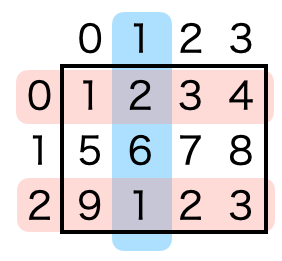

Suppose we want to extract `a[0,1]` and `a[2,1]`. Then, since index along axis 1 is fixed at 1, we can write as follows:

In [ ]:
# The list or array specified for axis 0 should align with the direction of axis to be returned
# This returns shape (1, 2)
print(a[[[0], [2]], 1])

# This returns shape (2,)
print(a[[0, 2], 1])

#### Example 2: Single row, multiple columns

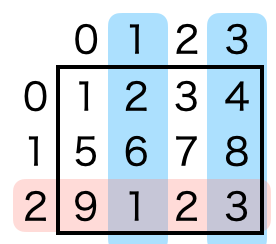

Suppose we want to extract `a[2,1]` and `a[2,3]`. Then, since index along axis 0 is fixed at 2, we can write as follows:

In [ ]:
# The list or array specified for axis 1 should align with the direction of axis to be returned
# This returns shape (1, 2)
print(a[2, [[1, 3]]])

# This returns shape (2,)
print(a[2, [1, 3]])

#### Example 3: Multiple rows, multiple columns

Now, how would you write it if you want to take multiple elements from each axis (i.e., extract a submatrix)?

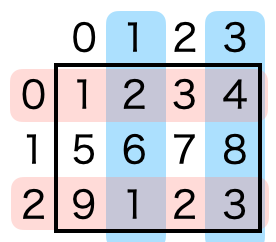

You can do the same as before by specifying a list or a 1D array for each axis.

In [ ]:
print(a[[[0], [2]], [[1, 3]]])

Note that the following will not result as the intended submatrix, as the list specifying axis 1 is not in the correct shape.

In [ ]:
print(a[[0, 2], [1, 3]]) # By doing this, a[0, 1] and a[2, 3] will be selected.

Here, the index `[[[0], [2]], [[1, 3]]]` is very difficult to read and hard to type. There is a function `np.ix_()` that returns `[[[0], [2]], [[1, 3]]]` when you provide `[0, 2], [1, 3]` as arguments.

In [ ]:
# The following two are the same
idx = np.ix_([0, 2], [1, 3])
print(a[idx])
print(a[[[0], [2]], [1, 3]])

### 2.5.2 Slicing

You can also use slices on each axis of a 2D array. A slice can be expressed as `start:end(:step)`, and to select all axes, you can use the slice `:`.

For example, we can retrieve the first 5 rows of `X` as follows.

In [ ]:
print("First 5 rows of X:", X[:5])

We can retrieve the first two columns (`TMAX`, `TMIN`) on a 3-day span as follows.

In [ ]:
print("TMAX and TMIN (3-day span):", X[::3, :2])

We can also retrieve `TMIN` and `PRCP` (last two columns) as follows.

In [ ]:
print("TMIN and PRCP (last 7 days):", X[:, -2:])

### 2.5.3 Boolean Indexing

Similar to 1D arrays, you can extract values where the corresponding index has a `True` value by specifying a 2D array with boolean values. In this case, the index must have the **same shape**.

For example, we can find the rows where `PRCP` is equal to 9999 (**missing value**).

In [ ]:
print("X (first 5 rows):", X[:5])

idx = (X == 999.9)
print("Boolean array of missing values (first 5 rows):", idx[:5])

You can also specify a boolean index to extract only specific axes.

In [ ]:
print("Only TMAX and PRCP:", X[:5, [True, False, True]])

NameError: name 'X' is not defined

Additionally, you can combine boolean indices with the `np.ix_()` function (see 2.5.1) to extract the intersecting parts.

In [ ]:
X_extracted = X[:5]
print(X_extracted)

print(X[np.ix_([True, True, False, False, False], [True, False, True])])

### <Practice Question 2-4>

(1) Create a 1-dimensional np.ndarray with 100 consecutive integers from 0 to 99, and reshape it into a 2-dimensional array with shape (10, 10).

In [ ]:
# WRITE ME

(2) From the array created in (1), extract the even rows (using 0-based indexing), resulting in a 2-dimensional array with shape (5, 10).

In [ ]:
# WRITE ME

(3) From the array created in (1), extract the odd columns (using 0-based indexing), resulting in a 2-dimensional array with shape (10, 5).

In [ ]:
# WRITE ME

(4) From the array created in (1), extract the values in even rows and odd columns (using 0-based indexing), resulting in a 2-dimensional array with shape (5, 5).

In [ ]:
# WRITE ME

## 2.6 Numpy Advanced

### 2.6.1 Constants
NumPy includes several constants:

In [ ]:
print("Pi:", np.pi)
print("Euler's number:", np.e)

`np.inf` which corresponds to $\infty$.

In [ ]:
print("Positive infinity:", np.inf)
print("Negative infinity:", - np.inf)

`np.inf` has the following properties in arithmetic operations.

In [ ]:
print(1 + np.inf)
print(1 - np.inf)
print(2 * np.inf)
print(2 / np.inf)

In addition, in conditional operations, it has the following properties regardless of the value of `a`.

In [ ]:
a = 10000000
print(a < np.inf)
print(-np.inf < a)

### 2.6.2 Numpy Arrays with Random Values

`numpy.random` module handles random numbers, allowing you to create arrays with random values. In this notebook, we have imported the module separately, so that we can use it more conveniently.

```python
from numpy import random
```

#### Uniform Distribution

To generate from a unifrom distribution, you can use `rand()` function.

In [ ]:
# Generate a uniform random number between [0, 1). 0 is included, but 1 is not.
print(random.rand())

# If a shape is provided as an argument, a uniform random array with that shape is generated
print(random.rand(5)) # A 1-dimensional array with length 5 (= shape (5, ))
print(random.rand(5, 5)) # A 2-dimensional array with shape (5, 5)

#### Normal Distribution

By using `randn()` instead of `rand()`, you can sample from a normal distribution.

In [ ]:
# Generate a random number following the standard normal distribution (mean 0, variance 1)
print(random.randn())

# If a shape is provided as an argument, random numbers with that shape are generated
print(random.randn(5)) # A 1-dimensional array with length 5 (=shape (5, ))
print(random.randn(5, 5)) # A 2-dimensional array with shape (5,5)

Also, if you want to specify the mean and standard deviation, you can use `normal(mean, std, shape)`.

In [ ]:
print(random.normal(100, 10)) # A random number from a normal distributionmean 100 and standard deviation 10
print(random.normal(100, 10, 5)) # A 1-dimensional array with 5 random numbers from a normal distribution with mean 100 and standard deviation 10
print(random.normal(100, 10, (5, 5)))
# A 2-dimensional array with shape (5,5) containing random numbers from a normal distribution with mean 100 and standard deviation 10

#### Random Integers

There is a function called `randint()` that generates random integers.

In [ ]:
print(random.randint(4)) # Generate a random integer between 0 and 3
print(random.randint(2, 10, (3, 3))) # Generate a 2-dimensional array with shape (3, 3) containing random integers between 2 and 9

#### Seed

The random number generation above produces different results each time it is executed. However, there are cases where you may want to fix the generated random numbers for reproducibility.

By setting a **seed** (the random number seed), you can ensure that the same random numbers are generated if the seed is the same.

In [ ]:
random.seed(seed=32) # The seed can be any integer

# The values will be the same no matter how many times you execute
print(random.rand(5))
print(random.rand(5))
print(random.randint(2, 10, (3, 3)))

### 2.6.3 Matrix Calculation

One of the highlights of Numpy is linear algebra calculations. Let's use the following arrays as an example.

In [ ]:
x = np.arange(1, 4)
y = np.arange(6, 9)
A = np.arange(1, 10).reshape(3, 3)
B = random.randint(1, 10, (3, 3))

print("x:", x)
print("y:", y)
print("A:", A)
print("B:", B)

#### Transpose

The transpose is an operation defined for two-dimensional arrays, and can be performed using `np.transpose()` or `np.ndarray.T`.

In [ ]:
# The following two are the same
print(np.transpose(A))
print(A.T)

[[ 5.05645125e-01 -4.24962470e-01 -5.10303679e-01  6.73392264e-01
   3.36371255e+00 -1.85857154e+00  1.52150885e+00 -6.81414713e-01
  -1.78791213e+00  9.66997738e-01  6.24443380e-02 -1.85337064e-01
   1.48436338e+00 -3.91573298e-01 -1.71300152e+00 -1.78332529e+00
   9.98657431e-01 -6.79982736e-01 -5.26311356e-01  1.36657358e+00
  -4.59934590e-01  2.03742962e-01 -8.11427183e-01 -3.90611028e-01
   4.24640107e-01 -4.67041100e-01 -1.21746422e+00 -8.07467933e-01
  -7.95059186e-01  1.14539813e-01  2.00774251e+00  8.67775449e-02
  -1.31167128e+00 -6.36603416e-02  1.31482178e+00  1.45978026e+00
   1.37582864e+00  1.74957541e+00  1.25856795e+00 -2.37874369e+00
  -5.86545200e-01 -3.46988565e-01 -8.03790864e-01 -7.36959852e-02
   7.96793173e-01  1.31263841e+00  4.83649078e-01 -4.94039685e-01
   6.08723784e-01  9.15413597e-02  3.91332586e-01 -1.07191903e+00
  -1.54969041e+00 -1.32528692e-01  6.30599785e-01  3.01407934e-01
   3.31685276e-01  1.15480260e+00 -7.86582002e-01  3.07956447e-01
   6.87739

#### Dot Product and Matrix Multiplication

The dot product and matrix multiplication can be performed using `np.dot()`, `np.matmul()`, or `@`. The differences between these methods are quite advanced and will be skipped here. For the level of this course, you can treat them as the same.

However, the `@` operator is not specific to Numpy; it was introduced in Python 3.5 as a built-in operator.

In [ ]:
print("Dot product of x and y")
print(np.dot(x, y))
print(np.matmul(x, y))
print(x @ y)

print("Matrix multiplication of A and B")
print(np.dot(A, B))
print(np.matmul(A, B))
print(A @ B)

Dot product of x and y
44
44
44
Matrix multiplication of A and B
[[ -2.78952119  -2.0851577    0.90326996]
 [ -2.37541421  -5.46395144  -4.99147867]
 [ -7.68188971  -2.9327116   -2.06512415]
 [ -2.88620795   2.28745788   4.79401832]
 [ 10.65244054   6.94584345  14.31926637]
 [ -8.93552178  -6.82442875  -9.38944153]
 [  3.78228298   8.04968096  10.41697094]
 [ -4.83224879  -5.33937681  -5.18142191]
 [-16.53004555 -28.00334587 -23.12769046]
 [  5.49651078   7.34101956   7.51612906]
 [ -7.24414636  -8.65720544  -4.46331231]
 [-10.63584809 -15.26143563  -9.43579442]
 [ 15.98127085  14.81446332  12.31080162]
 [-19.12802033 -27.40911522 -17.14533787]
 [-17.30118788 -17.20421307 -14.57336817]
 [  0.71628576   1.49312578  -5.30086564]
 [  9.14258186   5.02289634   4.9768278 ]
 [-11.1758376  -13.32624351  -9.58066281]
 [ -5.92832545   1.47229839   0.74421541]
 [ 19.02860776  23.87899301  17.93510034]
 [  6.06218296   9.90085001   4.3003207 ]
 [ 14.41973503  23.89779382  15.03151197]
 [-15.02094

In the following, we will use `np.matmul()`.

In [ ]:
# Since there are matrices, changing the order of multiplication does not guarantee the same result.
print(np.matmul(A, B))
print(np.matmul(B, A))

[[ -2.78952119  -2.0851577    0.90326996]
 [ -2.37541421  -5.46395144  -4.99147867]
 [ -7.68188971  -2.9327116   -2.06512415]
 [ -2.88620795   2.28745788   4.79401832]
 [ 10.65244054   6.94584345  14.31926637]
 [ -8.93552178  -6.82442875  -9.38944153]
 [  3.78228298   8.04968096  10.41697094]
 [ -4.83224879  -5.33937681  -5.18142191]
 [-16.53004555 -28.00334587 -23.12769046]
 [  5.49651078   7.34101956   7.51612906]
 [ -7.24414636  -8.65720544  -4.46331231]
 [-10.63584809 -15.26143563  -9.43579442]
 [ 15.98127085  14.81446332  12.31080162]
 [-19.12802033 -27.40911522 -17.14533787]
 [-17.30118788 -17.20421307 -14.57336817]
 [  0.71628576   1.49312578  -5.30086564]
 [  9.14258186   5.02289634   4.9768278 ]
 [-11.1758376  -13.32624351  -9.58066281]
 [ -5.92832545   1.47229839   0.74421541]
 [ 19.02860776  23.87899301  17.93510034]
 [  6.06218296   9.90085001   4.3003207 ]
 [ 14.41973503  23.89779382  15.03151197]
 [-15.0209468  -19.87343265 -13.98983293]
 [  2.83675332  12.85411813   7.56

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 3)

#### Side Note: Broadcasting
Broadcasting also occurs in matrix calculations. Let's look at the following example of calculating, $y=Ax$,

In [ ]:
# A simple example of broadcasting
print(np.matmul(A, x)) # x is interpreted as a column vector
print(np.matmul(x, A)) # x is interpreted as a row vector

#### Side Note: Row vectors vs. Column vectors
In many cases, when dealing with vectors (1-dimensional arrays), it is useful to distinguish between column vectors and row vectors. Therefore, it is often convenient to treat them as 2-dimensional arrays rather than 1-dimensional arrays. For example, when working with a 5-dimensional vector, using a 2-dimensional array with shape (5, 1) instead of a 1-dimensional array with shape (5,) allows operations like transposition to be performed.

In [ ]:
a = np.array([1, 0, 1, 0, 1]) # A 5-dimensional vector represented as a 1-dimensional array

# The transpose doesn't change anything (since there is only one axis)
print("Before transpose:", a)
print("After transpose:", a.T)

# By converting it into a 2-dimensional array, column and row vectors can be distinguished

# Convert a into a row vector as a 2-dimensional array
a = a.reshape(1, -1) # Using -1 for the axis automatically calculates the number of elements
print("Before transpose:", a)
print("After transpose:\n", a.T)

#### Linear Algebra Computation

Numpy includes a module called `linalg` that allows various linear algebra calculations.

```python
from numpy import linalg as LA
```

Here are some basic functions available in `linalg`.

In [ ]:
# Calculate the determinant
print(LA.det(A))
print(LA.det(B))

# Calculate the inverse matrix
print(LA.inv(B)) # Since B is a singular matrix, trying to compute its inverse will result in an error

In [ ]:
# Calculate the norm
# By default, it calculates the L2 norm
print(LA.norm(x))
print(LA.norm(y))

# By specifying the `ord` argument, it corresponds to the Lp norm
print(LA.norm(x, ord=1))
print(LA.norm(y, ord=np.inf)) # When `ord` is set to np.inf, it correctlycalculates the L∞ norm

Additionally, the `LA.norm()` function is an aggregation function, and when a multidimensional array is specified, you can use the `axis` argument. If `keepdims` is set to True, it will preserve the shape.

In [ ]:
print("A:")
print(A)

print()
print("keepdims=False (default)")
print("axis=0", LA.norm(A, axis=0))
print("axis=1", LA.norm(A, axis=1))

print()
print("keepdims=True")
print("axis=0")
print(LA.norm(A, axis=0, keepdims=True))
print("axis=1")
print(LA.norm(A, axis=1, keepdims=True))

In addition, `linalg` can be used to compute eigenvalues and singular values, as well as various matrix factorizations such as singular value decomposition (SVD) and LU decomposition.

## 2.7 Comprehensive Questions

Recently, in natural language processing using deep learning, models based on Google's Transformer have gained attention due to their human-level performance on several NLP tasks.

In January 2020, Google introduced [Reformer](https://arxiv.org/abs/2001.04451), which improves the time and space complexity of the Transformer model. In this task, we will implement a part of the Reformer paper, which uses [*cross-polytope LSH*](https://arxiv.org/abs/1509.02897) to improve the time complexity of the Transformer, with guided instructions.


Consider the following question:
>Given $n$ vectors, we want to assign the same integer value to "similar" vectors and different integer values to "dissimilar" vectors. In this context, "similar" vectors are those whose angle is close to 0.


The challenges of this problem are as follows:
- How small should the angle be for vectors to be considered "similar"?
- Even if vectors $a$ and $b$, and  $b$ and $c$ are "similar", $a$ and $c$ may not necessarily be considered "similar."
- To compute the angle $\theta$, we can use their inner product and norms to calculate $\cos \theta$. We could tehn sort htis value and assign integers accordingly, but sorting can become slow as $n$ increases (since the number of combinations of vectors is $_nC_2 = O(n^2)$).

We consider the following probablistic approach:

1. Rotate all vectors by the same random angle.

2. Vectors that are "similar" will, with **high probability**, remain in the same quadrant after rotation, while vectors that are "dissimilar" will, with **high probability**, end up in different quadrants.

3. Therefore, by assigning each vector an integer value corresponding to the quadrant it belongs to after the random rotation, the problem can be solved with **high probability**.

Let's implement this approach.



This time, we consider 100 3D row vectors.

In [ ]:
A = random.randn(100, 3) # A matrix stacked with 100 3D row vectors
print(A)

(1) Generate a rotation matrix $R$ that rotates 100 vectors, and compute the matrix of rotated vectors stacked vertically into a shape of (100, 3). Here, the 3D rotation matrix $R$ for a random rotation is generated by passing a 1D array of three randomly generated angle parameters to the `gen_R_3d` function.

In [ ]:
# (1)
def gen_R_3d(p):
    px, py, pz = p
    Rx = np.array([
        [1, 0, 0],
        [0, np.cos(px), np.sin(px)],
        [0, -np.sin(px), np.cos(px)]
    ])
    Ry = np.array([
        [np.cos(py), 0, -np.sin(py)],
        [0, 1, 0],
        [np.sin(py), 0, np.cos(py)]
    ])
    Rz = np.array([
        [np.cos(pz), np.sin(pz), 0],
        [-np.sin(pz), np.cos(pz), 0],
        [0, 0, 1]
    ])

    return Rz @ Ry @ Rx


(2) To normalize each vector obtained in (1) so that the L2 norm equals 1 and then stack them vertically to form a (100, 3) matrix, you would follow these steps:

Compute the L2 norm for each vector.
Normalize each vector by dividing by its L2 norm.
Stack the normalized vectors without changing their order.

In [ ]:
# (2)

(3) For the 100 vectors with a norm of 1 obtained in (2), compute a matrix of shape (100, 6) by stacking the original 100 vectors and their -1 multiplied counterparts **horizontally**, without changing the order of the vectors.

In [ ]:
# (3)

(4) (Somewhat Difficult)
Currently, in a 3D space, there are 8 quadrants numbered from 0 to 7. Instead of directly finding the quadrant, we will use 6 standard basis vectors and their inverse (6 vectors in total). The task is to find the "most similar" vector from this set.

After rotating the vectors, find the corresponding vector number and store it in a (100, 1) matrix.
(Hint: Think about how to assign the vector number using the normalized vectors. You can avoid using the inner product for efficiency. If you're unsure, try considering the case in 2D and then apply the same idea to 3D. You can utilize the normalization step from part (2).)

In [ ]:
# (4)

(5) (For those with extra time)
For the 100 vectors, calculate the cosine of the angle $\theta$ between every pair of vectors. Verify that vectors that are "similar" (i.e., have a small angle between them) are likely to have been assigned the same integer value, while vectors that are "dissimilar" (i.e., have a large angle between them) are likely to have been assigned different integer values.

In [ ]:
# (5)